# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [7]:
# Replace this list with your selected tickers- Industry: Motor Vehicles
# Tickers: Toyota, Honda, Tesla, Ferrari
tickers = ['TM', 'HMC', 'TSLA', 'RACE']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [8]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [9]:
# Download adjusted close prices
df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']

/tmp/ipython-input-3450391006.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']
[*********************100%***********************]  4 of 4 completed


In [10]:
df.head()

Ticker,HMC,RACE,TM,TSLA
Date,,,,
2020-01-02,23.760830,162.033814,121.410607,28.713333
2020-01-03,23.536904,161.050696,120.617402,30.266666
2020-01-06,23.271515,159.649009,120.165363,30.104000
2020-01-07,23.545199,159.485801,121.478844,31.441999
2020-01-08,23.404208,162.221978,120.753862,33.232666


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [15]:
#no null values so no need to clean missing values
df.isnull().sum()

,0
Ticker,
HMC,0
RACE,0
TM,0
TSLA,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [ ]:
# Add code here 🔧

In [18]:
daily_returns = df.pct_change().dropna()
daily_returns.head()

Ticker,HMC,RACE,TM,TSLA
Date,,,,
2020-01-03,-0.009424,-0.006067,-0.006533,0.054098
2020-01-06,-0.011275,-0.008703,-0.003748,-0.005374
2020-01-07,0.011760,-0.001022,0.010931,0.044446
2020-01-08,-0.005988,0.017156,-0.005968,0.056951
2020-01-09,-0.001417,0.012014,-0.002966,0.000622


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.





Daily Returns Volatility (Standard Deviation):
 Ticker
HMC     0.016942
RACE    0.017256
TM      0.015646
TSLA    0.037789
dtype: float64

Correlation Matrix of Daily Returns:
 Ticker       HMC      RACE        TM      TSLA
Ticker                                        
HMC     1.000000  0.357115  0.675029  0.221249
RACE    0.357115  1.000000  0.351889  0.331123
TM      0.675029  0.351889  1.000000  0.217041
TSLA    0.221249  0.331123  0.217041  1.000000


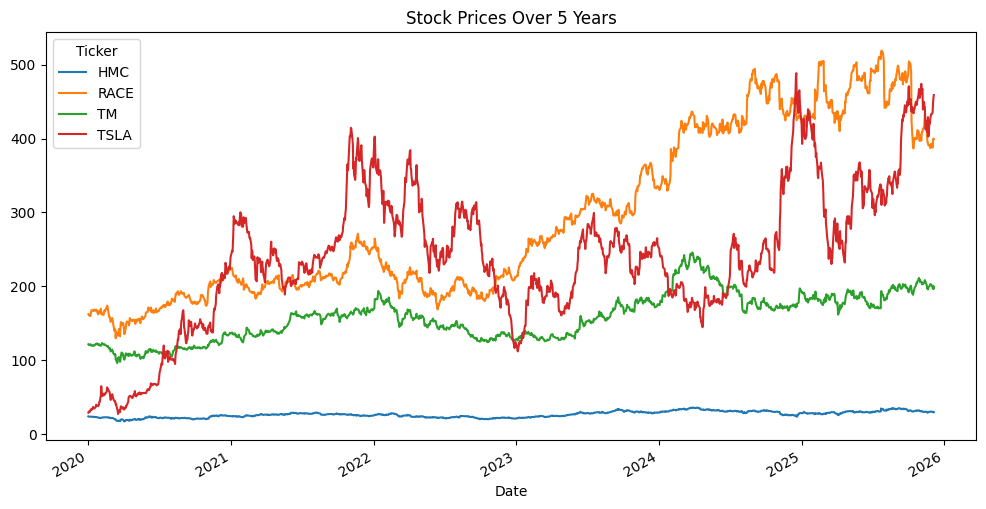

In [20]:
# 1. Create a line chart showing stock prices over the 5-year period.
df.plot(figsize=(12, 6), title='Stock Prices Over 5 Years')

# 2. Calculate the standard deviation of daily returns for each stock (volatility).
volatility = daily_returns.std()
print("\nDaily Returns Volatility (Standard Deviation):\n", volatility)

# 3. Create a correlation matrix of the daily returns between companies.
correlation_matrix = daily_returns.corr()
print("\nCorrelation Matrix of Daily Returns:\n", correlation_matrix)

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

Date: Dec, 7th, 2025

To: An Interested Stakeholder

From: Cassandra Nagy

Subject: Investment Evaluation on the Motor Vehicle Industry: Performance Analysis on 4 Companies

I analyzed the motor vehicle industry and it focuses on 4 companies, Toyota(TM), Honda(HMC), Tesla(TSLA), and Ferrari(RACE). My analytics focuses on 5 years of daily stock price highs from January 2020 to December 2025. I used this data to identify trends, see if the investment is a good fit and prepose different ways of finding a deeper analysis in the future. From looking at these stock price trends over the past 5 years, we can see some distinct trends. Tesla showed high growth and higher stock price fluctuations then the other more established companies like Toyota, Honda, and Ferrari. This is shown by the graph and the daily returns volatility, which is measured by the standard deviation. TSLA has a volatility of 0.0378, which is substantially higher than RACE (0.0173), HMC (0.0169), and TM (0.0156). This shows Tesla's stock has been considerably more volatile, which explains that it is both higher risk and has potential for larger returns. The correlation matrix shows a medium positive correlation between Toyota and Honda (0.675). This could mean that their stocks are more aligned probably due to similar market factors impacting the traditional car  manufactures. Ferrari and Tesla have weaker positive correlations  which may mean that their stock performance isn’t super aligned with the traditional market segments, especially Tesla who only produces electric vehicles.

Based on the evidence, an investment recommendation for the Motor Vehicle Industry depends on the investor’s risk tolerance and investment goals. An investor that is looking for high growth potential but is also able to tolerate a substantial amount of volatility should invest in Tesla. If the investor is looking for a more stable, slower growth investment, they should go with Toyota and Honda. Ferrari offers a mix of growth and medium volatility within the luxury car companies. As a whole industry, the trends are positive and especially with the continued transition to more electric vehicles and technological advancements, this would be a good investment opportunity. The individual companies within the industry show different risks, so it’s up to the stakeholder to choose what works best for them.

Future analytics or data sources that could strengthen our recommendations would be very useful. By incorporating earnings reports, sales by region, and future product development opportunities it could help provide deeper insights into the specific companies. In addition to this it would be helpful to see consumer spending trends and sentiment analysis from social media and articles, to help show a real gauge on the markets perspective. Lastly, we could use forecasting models as well as risk models to help with the analysis.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_14_LastnameFirstname.ipynb"